In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

def find_image(keyword, fallback_index):
  matches = [name for name in uploaded_names if keyword.lower() in name.lower()]
  if matches:
    return '/content/' + matches[0]

  if fallback_index < len(uploaded_names):
    return '/content/' + uploaded_names[fallback_index]
  raise FileNotFoundError(f"No Image Found With Keyword '{keyword}'")

image_paths = {
    'noisy.jpg': find_image('noisy', 0),
    'plate2.jpg': find_image('plate2', 1),
    'plate3.jpg': find_image('plate3', 2),
    'sudoku.jpg': find_image('sudoku', 3)
}

for name, path in image_paths.items():
  print(name, '->', path)

Saving noisy.jpg to noisy.jpg
Saving plate2.jpg to plate2.jpg
Saving plate3.jpg to plate3.jpg
Saving sudoku.jpg to sudoku.jpg
noisy.jpg -> /content/noisy.jpg
plate2.jpg -> /content/plate2.jpg
plate3.jpg -> /content/plate3.jpg
sudoku.jpg -> /content/sudoku.jpg


--- noisy.jpg ---
Global Threshold: 127.0
Otsu Threshold: 118.00
Blur + Otsu Threshold: 119.00


/tmp/ipykernel_2040/2206309154.py:26: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0, 256])
/tmp/ipykernel_2040/2206309154.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [0, 256])


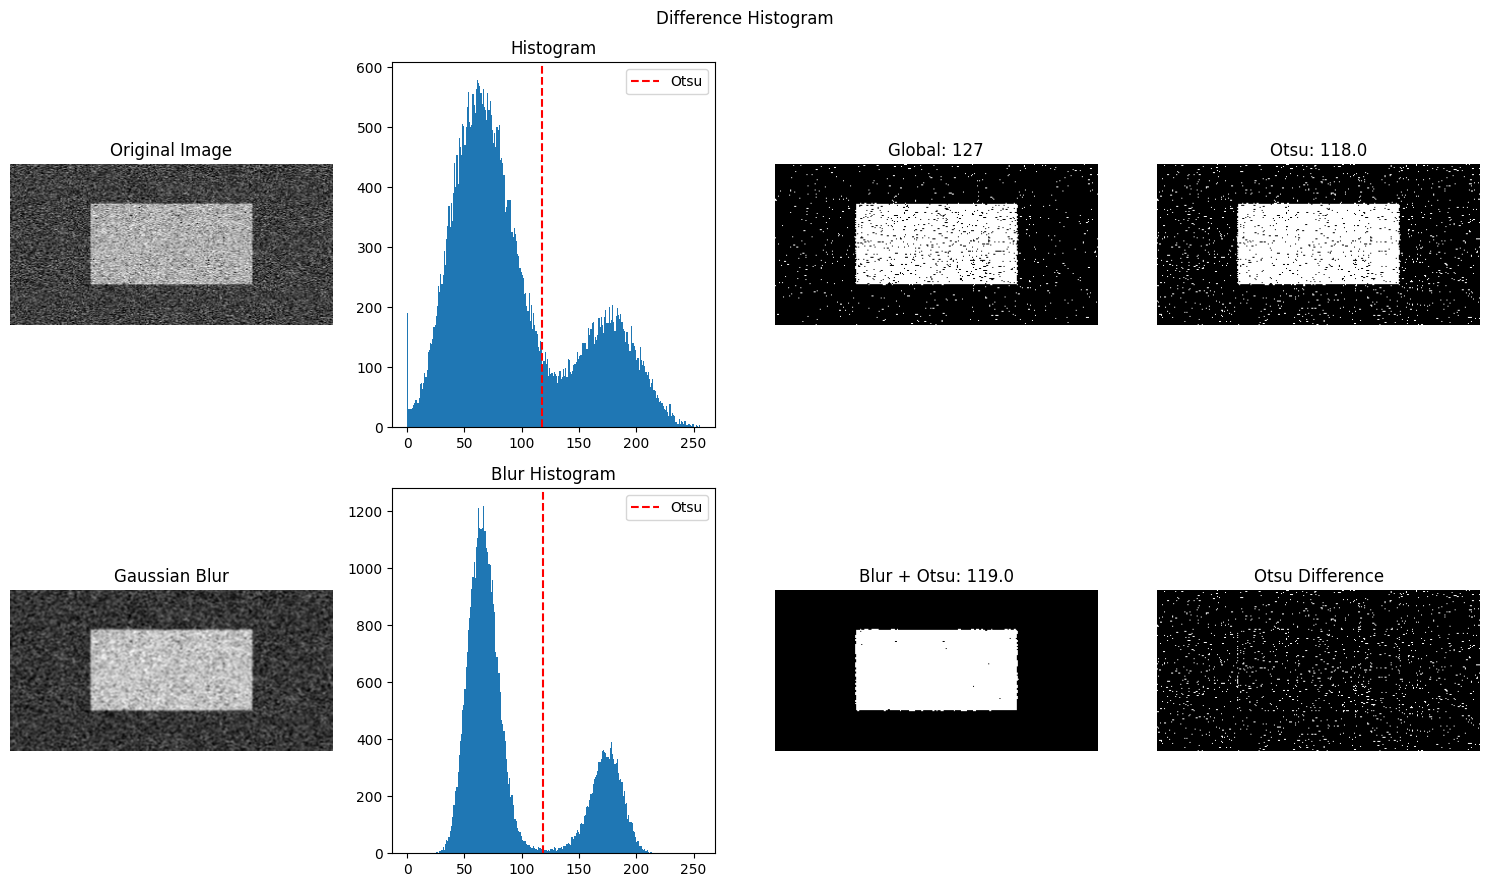

--- plate2.jpg ---
Global Threshold: 127.0
Otsu Threshold: 166.00
Blur + Otsu Threshold: 164.00


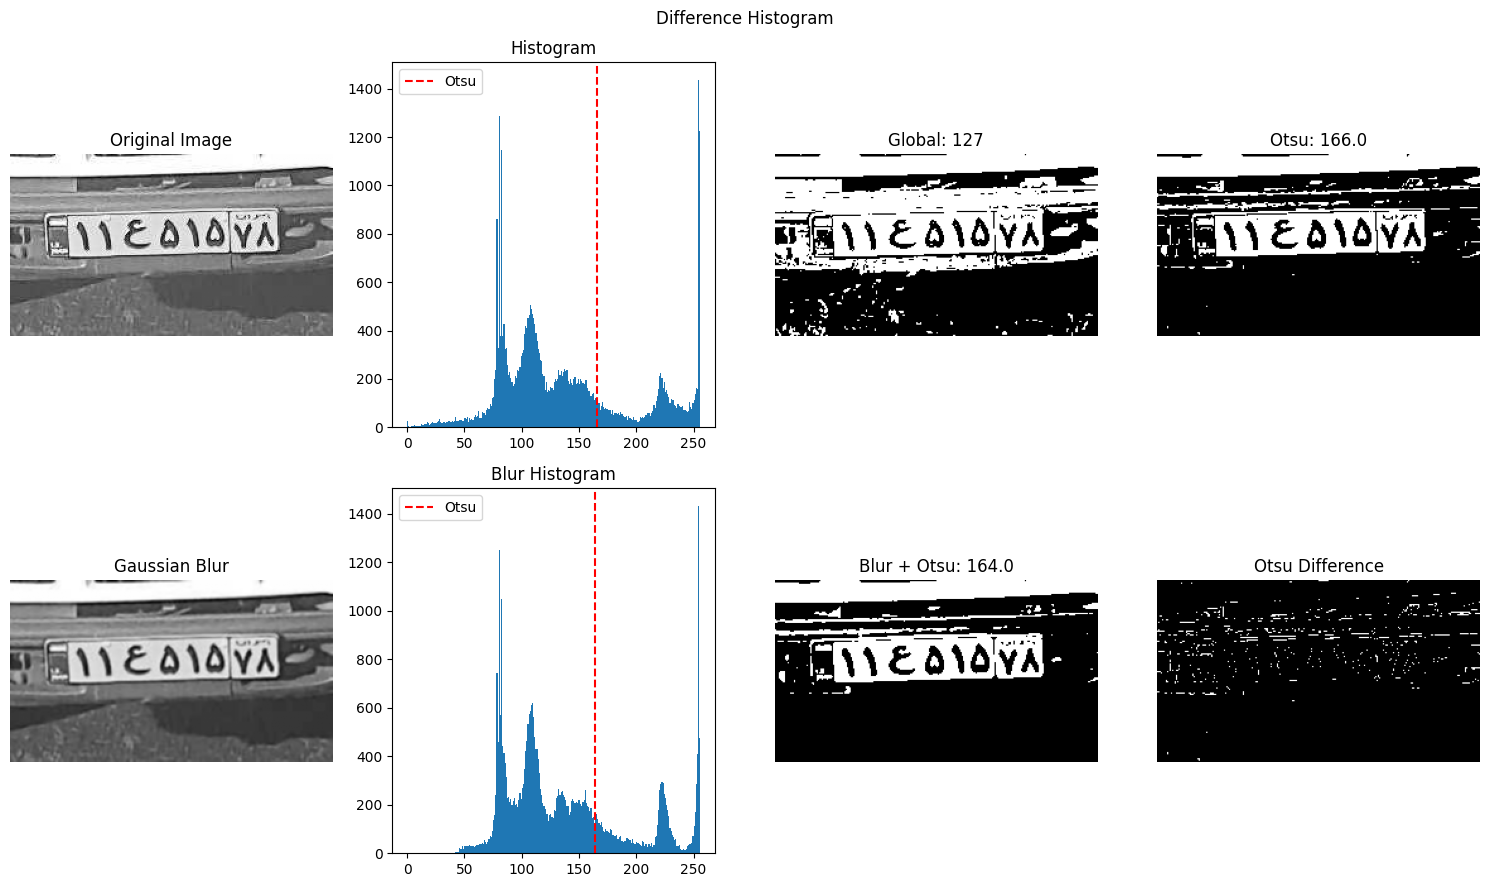

--- plate3.jpg ---
Global Threshold: 127.0
Otsu Threshold: 67.00
Blur + Otsu Threshold: 66.00


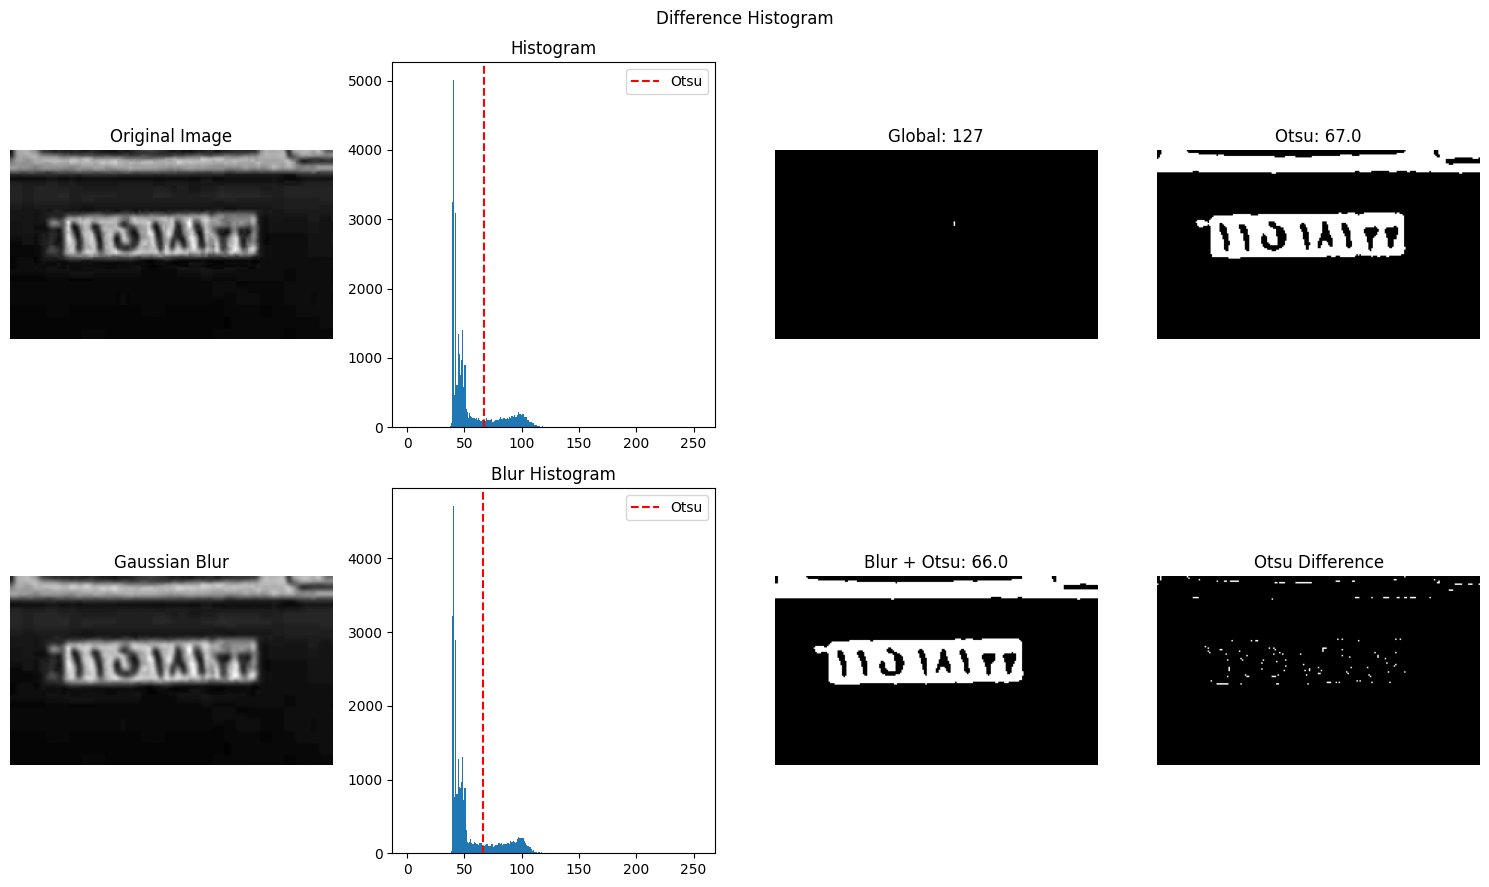

--- sudoku.jpg ---
Global Threshold: 127.0
Otsu Threshold: 96.00
Blur + Otsu Threshold: 97.00


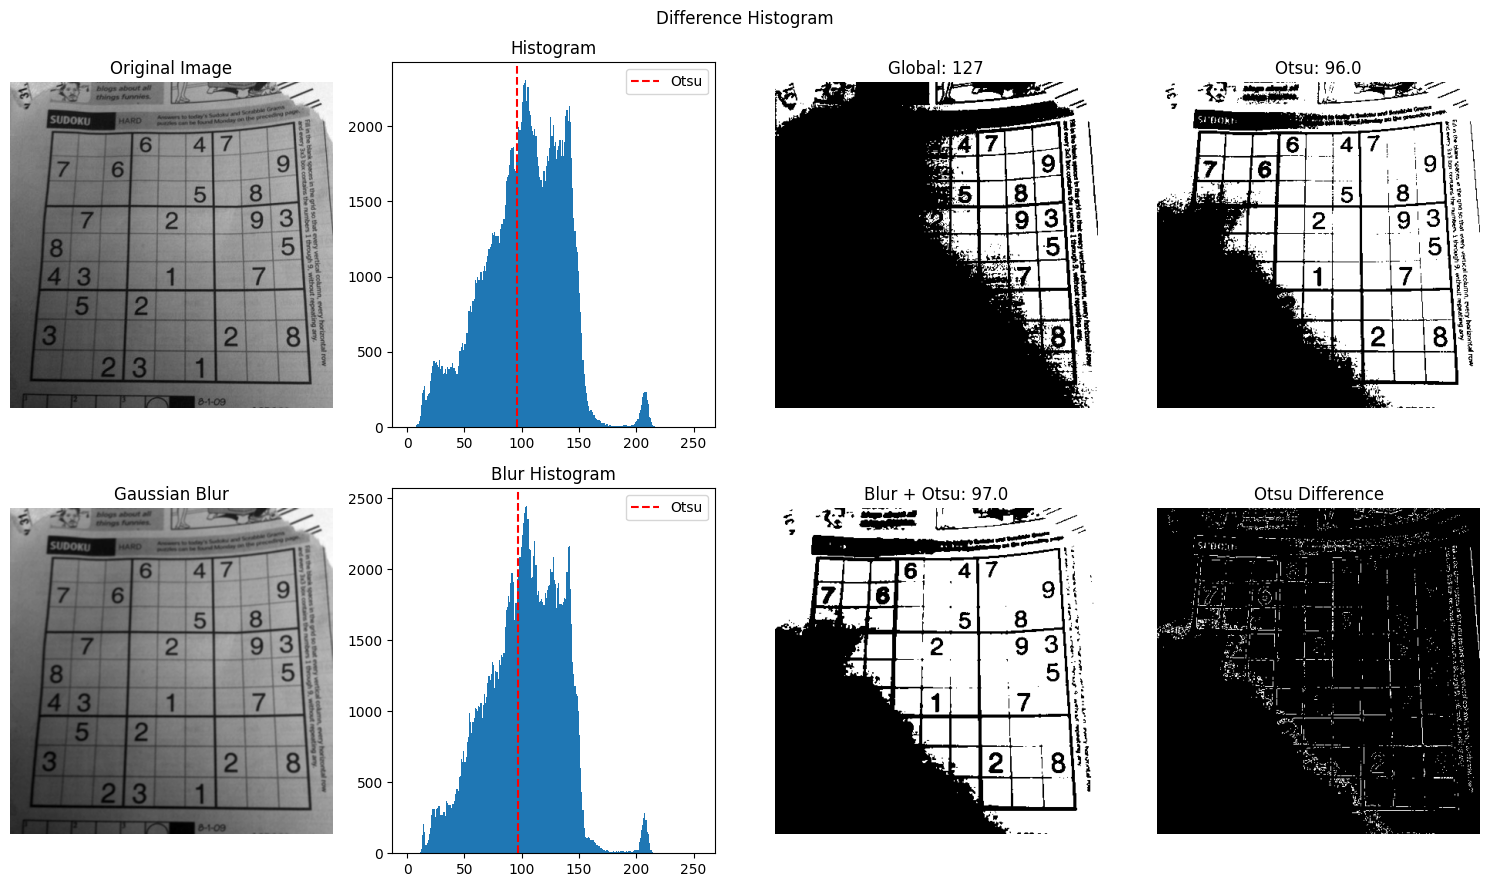

In [8]:
def compare_otsu(image_path, image_name, blur_kernel=(3, 3)):
  image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
  if image is None:
    raise ValueError(f"Image '{image_path}' Not Found")

  global_threshold, global_binary = cv.threshold(image, 127, 255, cv.THRESH_BINARY)

  otsu_threshold, otsu_binary = cv.threshold(image, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

  blur = cv.GaussianBlur(image, blur_kernel, 0)
  blur_otsu_threshold, blur_otsu_binary = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

  print(f'--- {image_name} ---')
  print(f'Global Threshold: {global_threshold}')
  print(f"Otsu Threshold: {otsu_threshold:.2f}")
  print(f"Blur + Otsu Threshold: {blur_otsu_threshold:.2f}")

  plt.figure(figsize=(15, 9))

  plt.subplot(2, 4, 1)
  plt.imshow(image, cmap='gray')
  plt.title('Original Image')
  plt.axis('off')

  plt.subplot(2, 4, 2)
  plt.hist(image.ravel(), 256, [0, 256])
  plt.axvline(otsu_threshold, color='r', linestyle='--', label='Otsu')
  plt.title('Histogram')
  plt.legend()

  plt.subplot(2, 4, 3)
  plt.imshow(global_binary, cmap='gray')
  plt.title('Global: 127')
  plt.axis('off')

  plt.subplot(2, 4, 4)
  plt.imshow(otsu_binary, cmap='gray')
  plt.title(f'Otsu: {otsu_threshold:.1f}')
  plt.axis('off')

  plt.subplot(2, 4, 5)
  plt.imshow(blur, cmap='gray')
  plt.title('Gaussian Blur')
  plt.axis('off')

  plt.subplot(2, 4, 6)
  plt.hist(blur.ravel(), 256, [0, 256])
  plt.axvline(blur_otsu_threshold, color='r', linestyle='--', label='Otsu')
  plt.title('Blur Histogram')
  plt.legend()

  plt.subplot(2, 4, 7)
  plt.imshow(blur_otsu_binary, cmap='gray')
  plt.title(f'Blur + Otsu: {blur_otsu_threshold:.1f}')
  plt.axis('off')

  plt.subplot(2, 4, 8)
  difference = cv.absdiff(blur_otsu_binary, otsu_binary)
  plt.imshow(difference, cmap='gray')
  plt.title('Otsu Difference')
  plt.axis('off')

  plt.suptitle('Difference Histogram')
  plt.tight_layout()
  plt.show()

  return {
      'original': image,
      'global_binary': global_binary,
      'otsu_binary': otsu_binary,
      'blur': blur,
      'blur_otsu_binary': blur_otsu_binary,
      'otsu_threshold': otsu_threshold,
      'blur_otsu_threshold': blur_otsu_threshold,
  }

results = {}
for image_name, image_path in image_paths.items():
  results[image_name] = compare_otsu(image_path, image_name)

In [11]:
print('Image'.ljust(15), 'Otsu'.rjust(12), 'Blur + Otsu'.rjust(15))
print('-' * 45)

for image_name, result in results.items():
  print(
      image_name.ljust(15),
      f"{result['otsu_threshold']:.2f}".rjust(12),
      f"{result['blur_otsu_threshold']:.2f}".rjust(15)
  )

Image                   Otsu     Blur + Otsu
---------------------------------------------
noisy.jpg             118.00          119.00
plate2.jpg            166.00          164.00
plate3.jpg             67.00           66.00
sudoku.jpg             96.00           97.00


In [10]:
output_paths = []

for image_name, result in results.items():
  stem = image_name.split('.')[0]
  otsu_path = f'/content/{stem}_otsu.png'
  blur_otsu_path = f'/content/{stem}_blur_otsu.png'

  cv.imwrite(otsu_path, result['otsu_binary'])
  cv.imwrite(blur_otsu_path, result['blur_otsu_binary'])
  output_paths.extend([otsu_path, blur_otsu_path])

  print('Saved:', otsu_path, 'And', blur_otsu_path)

Saved: /content/noisy_otsu.png And /content/noisy_blur_otsu.png
Saved: /content/plate2_otsu.png And /content/plate2_blur_otsu.png
Saved: /content/plate3_otsu.png And /content/plate3_blur_otsu.png
Saved: /content/sudoku_otsu.png And /content/sudoku_blur_otsu.png
